# Kunci Jawaban - Linear Regression

- **Dataset:** Concrete Slump Test
- **Target:** `Compressive Strength (28-day)(Mpa)`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, dan scatter plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Siapkan URL dataset UCI

Gunakan URL raw dataset Concrete Slump Test dari UCI.

In [5]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/slump/slump_test.data"

### Baca dataset CSV

Baca dataset raw UCI menjadi DataFrame bernama `df`.

In [6]:
df = pd.read_csv(DATA_URL)

### Tentukan kolom target

Tentukan kolom `Compressive Strength (28-day)(Mpa)` sebagai target prediksi.

In [7]:
TARGET_COL = "Compressive Strength (28-day)(Mpa)"

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [8]:
df.shape

(103, 11)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 103 baris dan 11 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [9]:
df.head()

,No,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,1,273.000,82.000,105.000,210.000,9.000,904.000,680.000,23.000,62.000,34.990
1,2,163.000,149.000,191.000,180.000,12.000,843.000,746.000,0.000,20.000,41.140
2,3,162.000,148.000,191.000,179.000,16.000,840.000,743.000,1.000,20.000,41.810
3,4,162.000,148.000,190.000,179.000,19.000,838.000,741.000,3.000,21.500,42.080
4,5,154.000,112.000,144.000,220.000,10.000,923.000,658.000,20.000,64.000,26.820


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya. Semua kolom berisi angka.

> Kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `Compressive Strength (28-day)(Mpa)`.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   No                                  103 non-null    int64  
 1   Cement                              103 non-null    float64
 2   Slag                                103 non-null    float64
 3   Fly ash                             103 non-null    float64
 4   Water                               103 non-null    float64
 5   SP                                  103 non-null    float64
 6   Coarse Aggr.                        103 non-null    float64
 7   Fine Aggr.                          103 non-null    float64
 8   SLUMP(cm)                           103 non-null    float64
 9   FLOW(cm)                            103 non-null    float64
 10  Compressive Strength (28-day)(Mpa)  103 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 9.0 KB

> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `int64` dan `float64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 103 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [11]:
df.isna().sum()

No                                    0
Cement                                0
Slag                                  0
Fly ash                               0
Water                                 0
SP                                    0
Coarse Aggr.                          0
Fine Aggr.                            0
SLUMP(cm)                             0
FLOW(cm)                              0
Compressive Strength (28-day)(Mpa)    0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [12]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk seluruh kolom numerik.

In [13]:
df.describe()

,No,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
count,103.000,103.000,103.000,103.000,103.000,103.000,103.000,103.000,103.000,103.000,103.000
mean,52.000,229.894,77.974,149.015,197.168,8.540,883.979,739.605,18.049,49.611,36.039
std,29.878,78.877,60.461,85.418,20.208,2.808,88.391,63.342,8.751,17.569,7.838
min,1.000,137.000,0.000,0.000,160.000,4.400,708.000,640.600,0.000,20.000,17.190
25%,26.500,152.000,0.050,115.500,180.000,6.000,819.500,684.500,14.500,38.500,30.900
50%,52.000,248.000,100.000,164.000,196.000,8.000,879.000,742.700,21.500,54.000,35.520
75%,77.500,303.900,125.000,235.950,209.500,10.000,952.800,788.000,24.000,63.750,41.205
max,103.000,374.000,193.000,260.000,240.000,19.000,1049.900,902.000,29.000,78.000,58.530


> Berdasarkan statistik deskriptif, berapa rata-rata target?

Jawaban: Rata-rata target sekitar 36.039.

> Berdasarkan statistik deskriptif, berapa nilai minimum dan maksimum target?

Jawaban: Minimum target 17.190 dan maksimum target 58.530.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [14]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [15]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [16]:
df_clean.shape

(103, 11)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 103 baris dan 11 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [17]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `Compressive Strength (28-day)(Mpa)`.

In [18]:
df_clean[TARGET_COL].describe()

count   103.000
mean     36.039
std       7.838
min      17.190
25%      30.900
50%      35.520
75%      41.205
max      58.530
Name: Compressive Strength (28-day)(Mpa), dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 36.039, minimum 17.190, dan maksimum 58.530.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target.

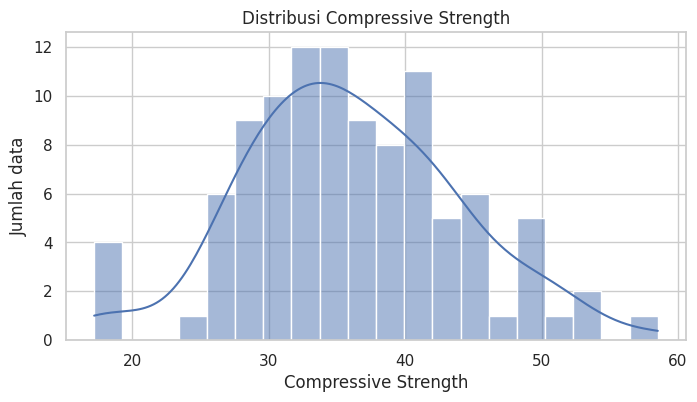

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=20, kde=True)
plt.title("Distribusi Compressive Strength")
plt.xlabel("Compressive Strength")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang sekitar 31.659 sampai 33.726.

> Apakah distribusi target terlihat sangat miring atau relatif menyebar di sekitar tengah?

Jawaban: Distribusi target relatif menyebar di sekitar tengah dan tidak terlalu ekstrem.

### Hitung korelasi fitur bahan dengan target

Hitung korelasi fitur bahan beton terhadap target.

In [20]:
modeling_columns = df_clean.drop(columns=["No", "SLUMP(cm)", "FLOW(cm)"])
numeric_corr = modeling_columns.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

Cement          0.446
Fly ash         0.444
SP             -0.038
Fine Aggr.     -0.154
Coarse Aggr.   -0.161
Water          -0.254
Slag           -0.332
Name: Compressive Strength (28-day)(Mpa), dtype: float64

> Berdasarkan output korelasi, fitur apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `Cement` memiliki korelasi positif paling tinggi terhadap target.

> Fitur apa yang memiliki korelasi negatif paling kuat terhadap target?

Jawaban: Fitur `Slag` memiliki korelasi negatif paling kuat terhadap target.

### Buat bar plot korelasi fitur bahan

Gunakan bar plot untuk melihat kekuatan korelasi fitur bahan dengan target.

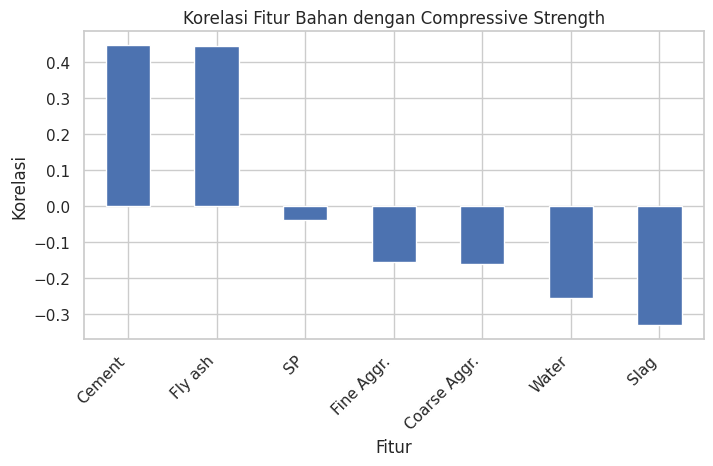

In [21]:
plt.figure(figsize=(8, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur Bahan dengan Compressive Strength")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur mana yang paling positif hubungannya dengan target?

Jawaban: `Cement` paling positif hubungannya dengan target.

> Fitur mana yang paling negatif hubungannya dengan target?

Jawaban: `Slag` paling negatif hubungannya dengan target.

### Buat scatter plot Cement dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan `Cement` dengan target.

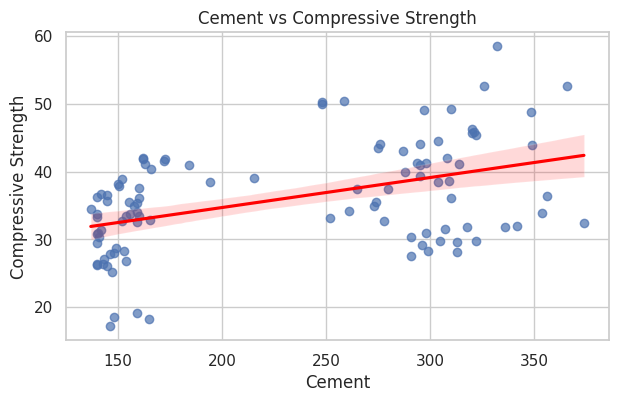

In [22]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="Cement", y=TARGET_COL, scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("Cement vs Compressive Strength")
plt.xlabel("Cement")
plt.ylabel("Compressive Strength")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `Cement` dengan target?

Jawaban: Polanya cenderung positif; semakin tinggi `Cement`, target cenderung lebih tinggi.

> Apakah garis regresi menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis regresi menunjukkan arah hubungan positif.

### Buat scatter plot Water dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan `Water` dengan target.

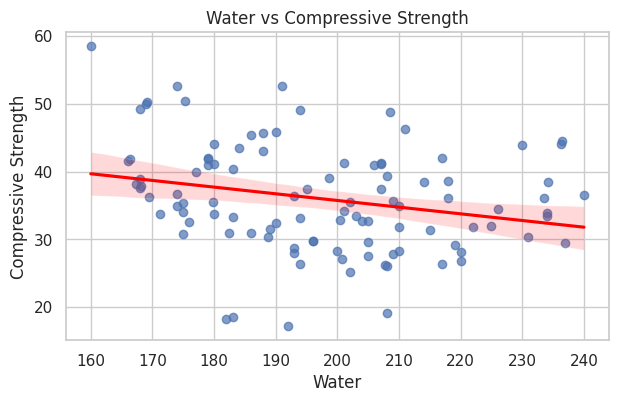

In [23]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="Water", y=TARGET_COL, scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("Water vs Compressive Strength")
plt.xlabel("Water")
plt.ylabel("Compressive Strength")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `Water` dengan target?

Jawaban: Polanya cenderung negatif; semakin tinggi `Water`, target cenderung lebih rendah.

> Apakah garis regresi menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis regresi menunjukkan arah hubungan negatif.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan fitur bahan dengan menghapus target, nomor baris, dan output pengujian lain.

In [24]:
X_raw_model = df_clean.drop(columns=[TARGET_COL, "No", "SLUMP(cm)", "FLOW(cm)"])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [25]:
y = df_clean[TARGET_COL]

### Gunakan fitur numerik

Gunakan fitur numerik yang sudah tersedia karena dataset ini tidak memiliki kolom kategori.

In [26]:
X = X_raw_model.copy()

### Tampilkan ukuran fitur

Tampilkan ukuran `X` yang akan digunakan untuk modeling.

In [27]:
X.shape

(103, 7)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki 103 baris dan 7 fitur.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [28]:
y.shape

(103,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 103 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [31]:
X_train.shape

(82, 7)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [32]:
X_test.shape

(21, 7)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 82 baris dan data test memiliki 21 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [33]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [34]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [35]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [36]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [37]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [38]:
model.intercept_

np.float64(35.8480487804878)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 35.848.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [39]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
0,Cement,4.465
2,Fly ash,4.278
4,SP,0.329
1,Slag,-2.018
6,Fine Aggr.,-2.597
3,Water,-4.831
5,Coarse Aggr.,-5.313


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `Cement` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `Coarse Aggr.` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [40]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [41]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [42]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,45.820,45.283
1,40.340,42.197
2,28.290,28.908
3,43.010,40.283
4,33.510,35.270


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris pertama terlihat paling dekat karena actual 45.820 dan predicted sekitar 45.283.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris keempat terlihat paling jauh karena actual 43.010 dan predicted sekitar 40.283.

### Hitung MAE train

Hitung MAE pada data train.

In [43]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

1.9428993298939738

### Hitung MAE test

Hitung MAE pada data test.

In [44]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

1.7310164358874036

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 1.731.

### Hitung RMSE train

Hitung RMSE pada data train.

In [45]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(2.6255938994792922)

### Hitung RMSE test

Hitung RMSE pada data test.

In [46]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(2.068522874433819)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 2.069.

### Hitung R2 train

Hitung R2 Score pada data train.

In [47]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.8910687695323618

### Hitung R2 test

Hitung R2 Score pada data test.

In [48]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.9154343520428141

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.915.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [49]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,1.943,2.626,0.891
1,Test,1.731,2.069,0.915


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 10.91% lebih rendah daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 21.22% lebih rendah daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 2.73% lebih tinggi daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

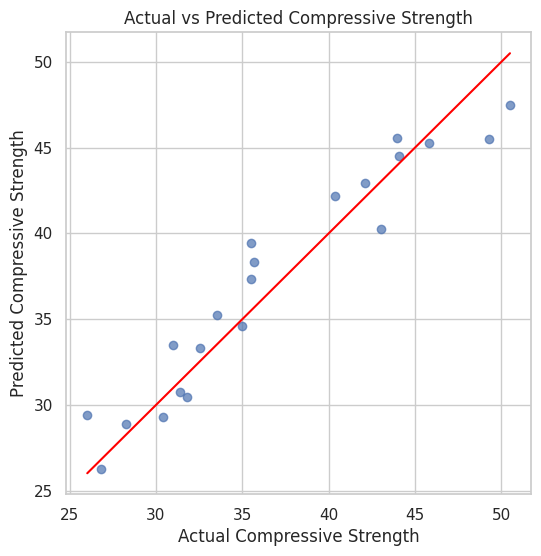

In [50]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Compressive Strength")
plt.xlabel("Actual Compressive Strength")
plt.ylabel("Predicted Compressive Strength")
plt.show()

## 11 - Kesimpulan

Dataset Concrete Slump Test digunakan untuk memprediksi `Compressive Strength (28-day)(Mpa)` berdasarkan komposisi bahan beton. Dataset memiliki 103 baris dan 11 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `Compressive Strength (28-day)(Mpa)` relatif menyebar di sekitar tengah. Fitur bahan dengan korelasi positif paling tinggi terhadap target adalah `Cement`, sedangkan fitur dengan korelasi negatif paling kuat adalah `Slag`. Kolom `No`, `SLUMP(cm)`, dan `FLOW(cm)` dihapus sebelum modeling.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 1.731, RMSE test sekitar 2.069, dan R2 test sekitar 0.915.